# Практика: DBSCAN — плотностная кластеризация

## Что вы сделаете
В этом ноутбуке вы:

1. исследуете нелинейные 2D-датасеты и убедитесь в ограничениях K-Means;
2. построите **k-distance plot** и выберете оптимальный параметр `eps`;
3. применените **DBSCAN** и проанализируете результаты;
4. сравните DBSCAN с K-Means на нелинейных данных;
5. исследуете влияние гиперпараметров `eps` и `min_samples`;
6. применените DBSCAN к реальному датасету **Wine** и проанализируете шумовые точки;
7. сравните силуэт DBSCAN и K-Means, сделаете выводы.

## Важно
- Заполняйте все ячейки с пометкой `# YOUR CODE HERE`.
- Не удаляйте проверки: они подскажут, правильно ли вы идёте.
- Вопросы для размышления помогут вам глубже понять алгоритм.

## Датасеты
- **`make_moons`** и **`make_circles`** из `sklearn.datasets`: 2D-данные с нелинейными кластерами.
- **Wine** (`load_wine`): реальный многомерный датасет (13 признаков, 3 класса).

## Что сдавать
1. Заполненный ноутбук со всеми графиками.
2. Краткие выводы в конце каждого раздела.
3. Итоговый вывод: когда DBSCAN лучше K-Means и когда нет.

## Краткая теория

### Типы точек в DBSCAN

DBSCAN задаётся двумя параметрами: радиусом окрестности `eps` (ε) и минимальным числом точек `min_samples`.

- **Корневая точка** (core): в её ε-окрестности ≥ `min_samples` точек.
- **Граничная точка** (border): в её ε-окрестности < `min_samples`, но она достижима из корневой.
- **Шумовая точка** (noise): не является ни корневой, ни граничной → метка **-1**.

### Как работает алгоритм

1. Для каждой непосещённой точки найти её ε-окрестность.
2. Если точек ≥ `min_samples` — начать новый кластер.
3. Рекурсивно расширить кластер через цепочки плотно достижимых точек.
4. Оставшиеся точки → шум (метка -1).

### Как выбрать eps: k-distance plot

Для каждой точки вычисляют расстояние до её k-го ближайшего соседа (k = `min_samples`). Отсортированный по убыванию график этих расстояний называется **k-distance plot**. Резкий перегиб («локоть») указывает на оптимальное значение `eps`.

---
## Шаг 1. Импорты и настройки

In [542]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Для воспроизводимости
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Импорты выполнены успешно!")

Импорты выполнены успешно!


---
## Шаг 2. Исследование нелинейных датасетов

Сгенерируем два датасета, с которыми K-Means заведомо не справится.

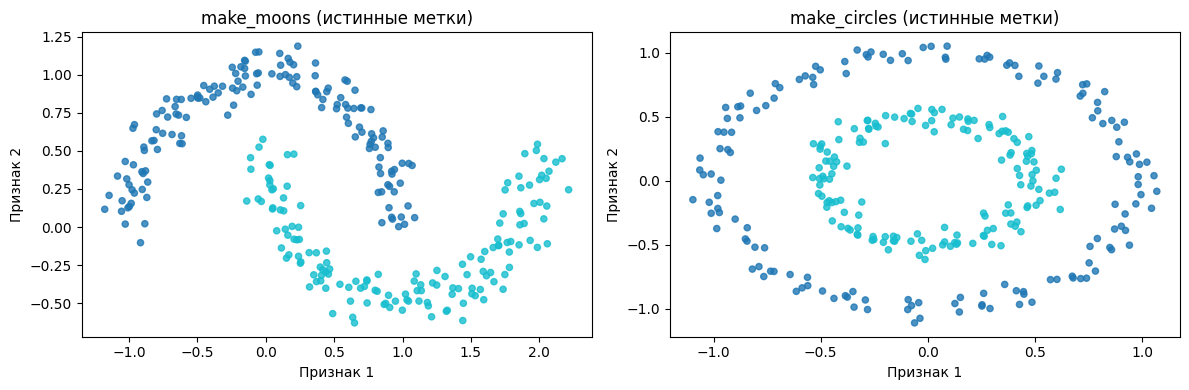

In [543]:
# Генерация датасетов
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05,
                                     factor=0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=y_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

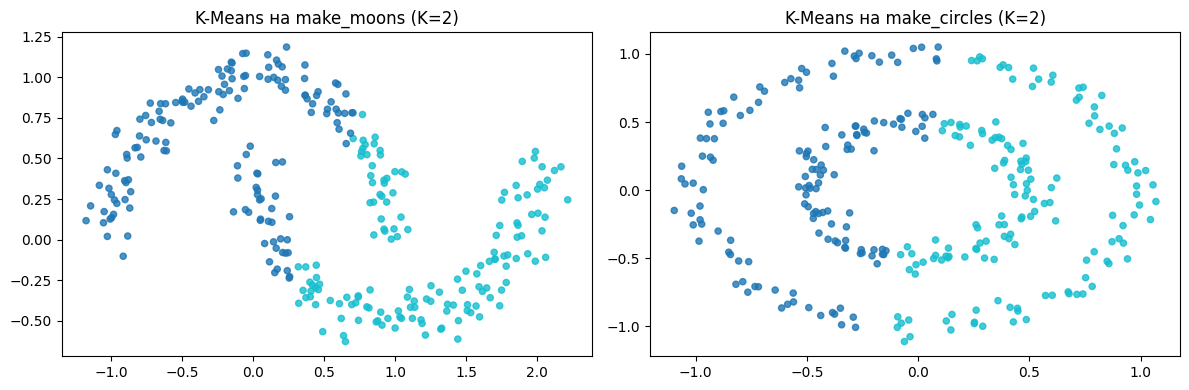

In [544]:
# Применим K-Means к этим датасетам
# YOUR CODE HERE
# 1. Создайте KMeans с n_clusters=2, random_state=RANDOM_STATE
# 2. Обучите на X_moons и X_circles
# 3. Получите метки кластеров

kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

kmeans_circles = KMeans(n_clusters=2, random_state=RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

# Визуализация результатов K-Means
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1],
                c=labels_km_moons, cmap='tab10', s=20, alpha=0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1],
                c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** Почему K-Means не может правильно разделить «луны» и «кольца»? Связано ли это с формой функционала ошибки?

Ответ: это связано с функцией ошибок, которую минимизирует K-Means. Он минимизирует расстояния, а значит форма, получаемся в результате, будет напоминать круг. Данные же имеют нелинейные зависимости, которые K_Means обнаружить не в силах.

---
## Шаг 3. k-Distance Plot и выбор eps

Построим k-distance plot для датасета `make_moons`. Используем k = 5 (= `min_samples`).

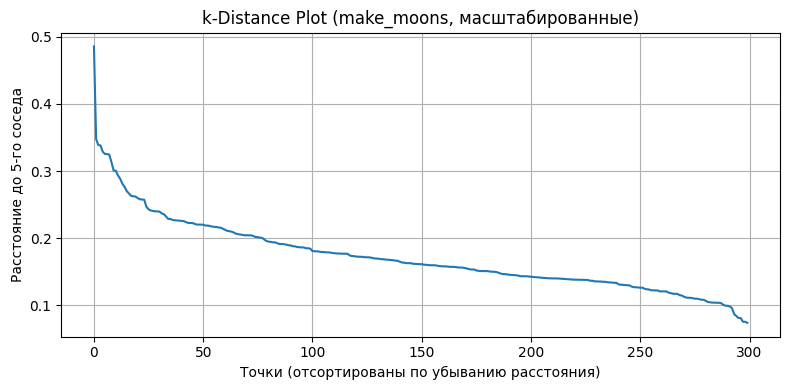

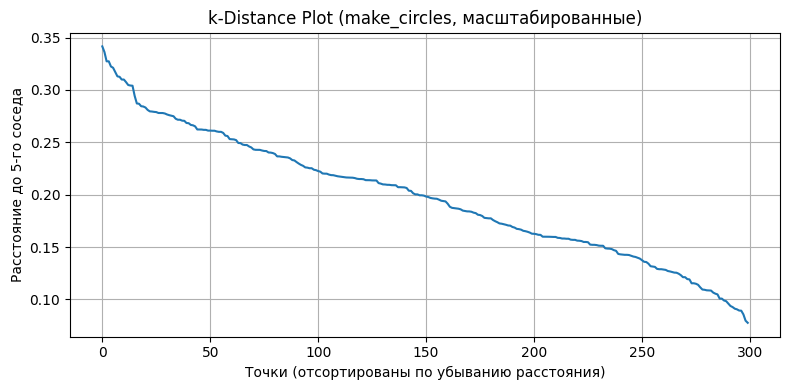

Найдите 'локоть' на графике и запишите подходящее значение eps:


In [545]:
# Масштабируем данные
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

k = 5

# YOUR CODE HERE
# 1. Создайте NearestNeighbors(n_neighbors=k) и обучите на X_moons_scaled
# 2. Вызовите .kneighbors() для получения матрицы расстояний
# 3. Возьмите расстояние до k-го соседа (последний столбец distances)
# 4. Отсортируйте по убыванию

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons_scaled)
distances_moons, indices = nn.kneighbors()
k_distances_moons = distances_moons[:, -1]
k_distances_moons = sorted(k_distances_moons)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

nn2 = NearestNeighbors(n_neighbors=k)
nn2.fit(X_circles_scaled)
distances_circles, indices2 = nn2.kneighbors()
k_distances_circles = distances_circles[:, -1]
k_distances_circles = sorted(k_distances_circles)[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_circles)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_circles, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

print("Найдите 'локоть' на графике и запишите подходящее значение eps:")

**❓ Вопрос для размышления:** Где находится «локоть»? Как он указывает на границу между точками кластеров и шумом?

Ответ: локоть находится примерно на уровне eps=0.27 . Как он указывает на границу - понятия не имею... Что это вообще значит? eps = локоть - это компромисс между бесконечным числом кластеров (малый eps) и одним огромным кластером (большой eps). Точки левее далеко друг от друга достаточно, чтобы считаться шумом. Точки правее - части некоторых кластеров.

---
## Шаг 4. DBSCAN на нелинейных датасетах

Применим DBSCAN к `make_moons` и `make_circles`. Обратите внимание на масштабирование.

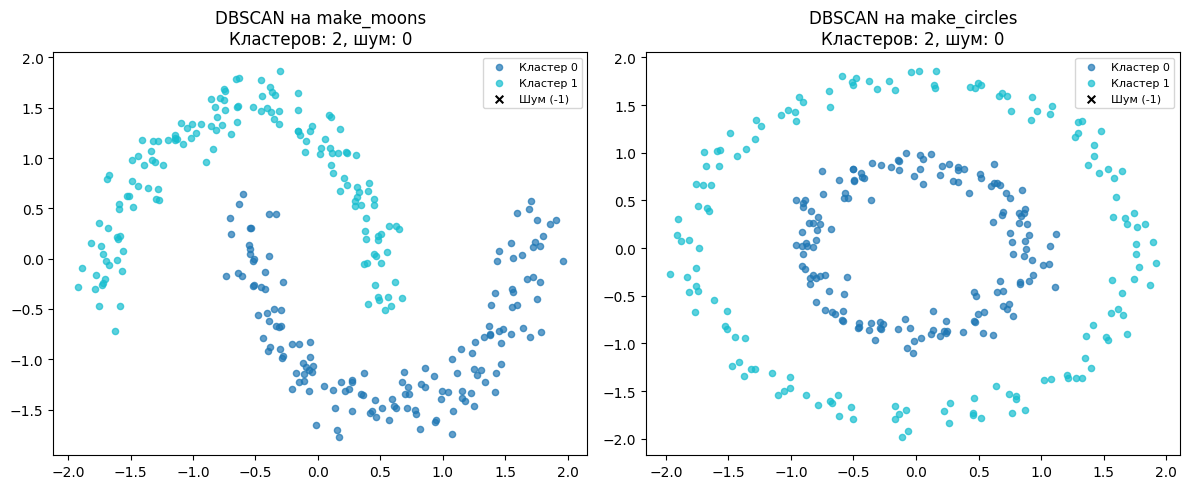

In [546]:
# Масштабируем make_circles
scaler_circles = StandardScaler()
X_circles_scaled = scaler_circles.fit_transform(X_circles)

# YOUR CODE HERE
# 1. Создайте DBSCAN с подобранным eps (из k-distance plot) и min_samples=5
# 2. Примените fit_predict к X_moons_scaled и X_circles_scaled
# 3. Подберите параметры так, чтобы алгоритм нашёл 2 кластера

db_moons = DBSCAN(eps=0.3, min_samples=5)
labels_db_moons = db_moons.fit_predict(X_moons_scaled)

db_circles = DBSCAN(eps=0.35, min_samples=5)
labels_db_circles = db_circles.fit_predict(X_circles_scaled)

# Вспомогательная функция для визуализации
def plot_dbscan_results(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []
    
    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_dbscan_results(X_moons_scaled, labels_db_moons, "DBSCAN на make_moons", axes[0])
plot_dbscan_results(X_circles_scaled, labels_db_circles, "DBSCAN на make_circles", axes[1])
plt.tight_layout()
plt.show()

Важный вывод: значения eps в локте - скорее минимум, когд точки начинают объединяться в видимые кластеры, нежели панацея. Ибо на практике, как мы видим выше, eps=[0.3, 0.35] поделило данные идеально, в то время как eps = локоть (0.2) посоздавал ещё пару тройку кластеров.

---
## Шаг 5. Сравнение DBSCAN и K-Means на нелинейных данных

In [547]:
# Сравнение силуэта DBSCAN vs K-Means для make_moons

# YOUR CODE HERE
# 1. Обучите KMeans(n_clusters=2) на X_moons_scaled
# 2. Вычислите silhouette_score для K-Means
# 3. Вычислите silhouette_score для DBSCAN (только для некластерных точек!)
#    Подсказка: исключите точки с labels == -1

nn3 = KMeans(n_clusters=2, random_state=RANDOM_STATE)
kmeans_moons_scaled = nn3.fit_predict(X_moons_scaled)
score_kmeans = silhouette_score(X_moons_scaled, kmeans_moons_scaled)

mask = labels_db_moons != -1
if len(set(labels_db_moons[mask])) >= 2:
    score_dbscan = silhouette_score(X_moons_scaled[mask], labels_db_moons[mask])
else:
    score_dbscan = None


print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.494
DBSCAN:        0.380


**❓ Вопрос для размышления:** Какой алгоритм получил лучший силуэт? Соответствует ли это визуальному впечатлению? Можно ли всегда доверять силуэту как абсолютной мере качества?

Если я не ошибся, победил как раз-таки K-Means. Визуально, правда, DBSCSAN явно справился получше. Из этого следует вывод, что метрика силуэт - не панацея. Причина тому - она считает расстояния в Евклидовом пространстве, а значит ревностно относится к нелинейным зависимостям. Таким образом, силуэт хорош для оценки качества работы алгоритма K-Means, но не более того.

---
## Шаг 6. Исследование влияния гиперпараметров

Посмотрим, как меняется результат DBSCAN при разных значениях `eps` и `min_samples`.

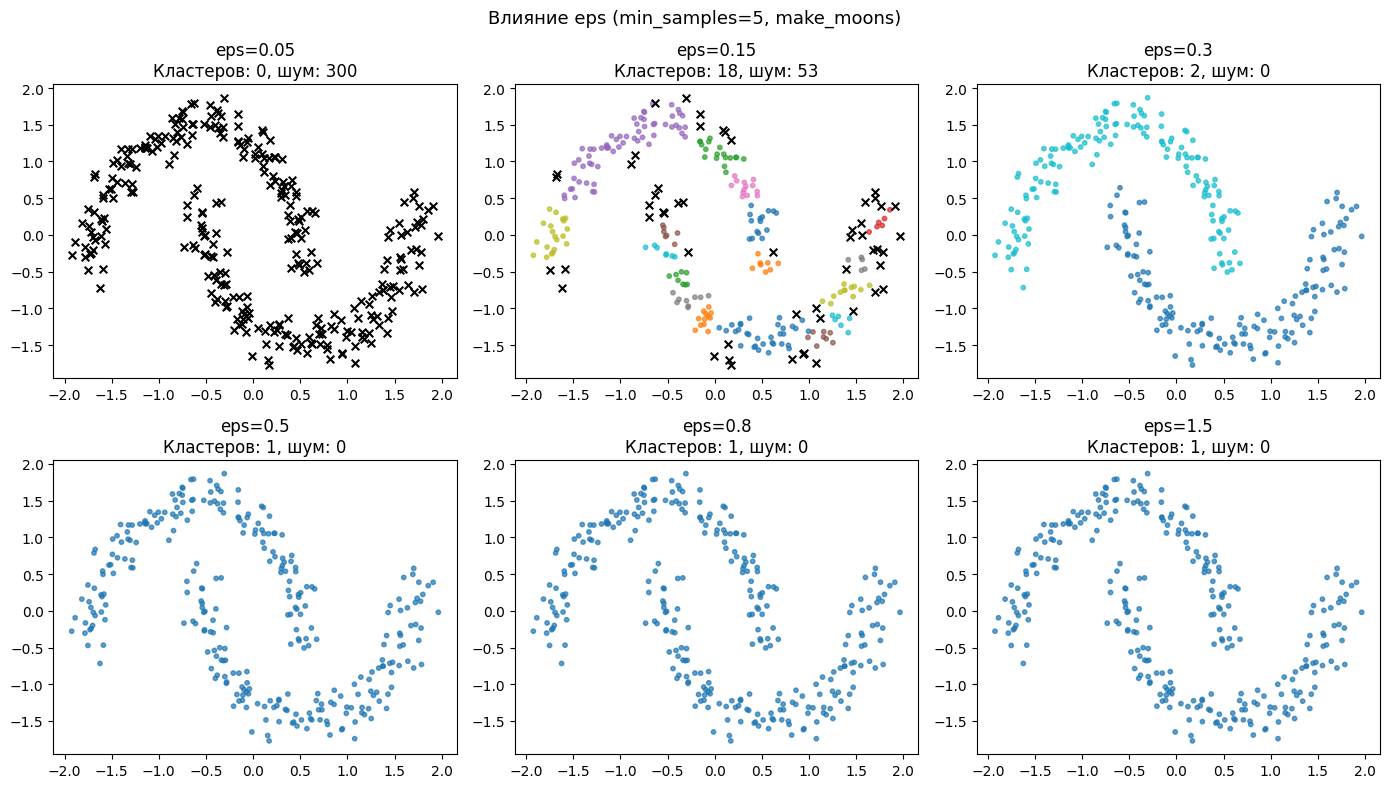

In [548]:
# Сетка eps при фиксированном min_samples=5
eps_values = [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    # YOUR CODE HERE
    # 1. Запустите DBSCAN(eps=eps_val, min_samples=5) на X_moons_scaled
    # 2. Получите метки
    # 3. Посчитайте число кластеров и шумовых точек
    # 4. Отобразите scatter plot с цветами по меткам
    #    Шумовые точки (label == -1) рисуйте чёрными крестиками
    model_i = DBSCAN(eps=eps_val, min_samples=5)
    labels_i = model_i.fit_predict(X_moons_scaled)
    
    if labels_i is not None:
        n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
        n_noise = (labels_i == -1).sum()
        axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")
        noise = labels_i == -1
        axes[i].scatter(X_moons_scaled[~noise, 0], X_moons_scaled[~noise, 1],
                c=labels_i[~noise], cmap='tab10', s=10, alpha=0.7)
        axes[i].scatter(X_moons_scaled[noise, 0], X_moons_scaled[noise, 1],
                c='black', marker='x', s=30, label='шум')
    else:
        axes[i].set_title(f"eps={eps_val} (не вычислено)")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()

**❓ Вопрос для размышления:** При каком `eps` алгоритм нашёл два правильных кластера? Что происходит при слишком малом и слишком большом значении?

Ответ: нашёл, как и предсказывалось выше, при eps=0.3! Слишком малый eps - данные есть сплошной шум с точки зрения модели. Малый eps - данные есть единый кластер.

---
## Шаг 7. DBSCAN на реальном датасете Wine

Теперь перейдём к реальным данным. Датасет Wine: 178 образцов вина из трёх сортов винограда, 13 химических признаков.

In [549]:
# Загрузка датасета Wine
wine = load_wine()
X_wine = wine.data
y_wine = wine.target  # истинные метки (не используем при кластеризации!)
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))
print(y_wine)

Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00             

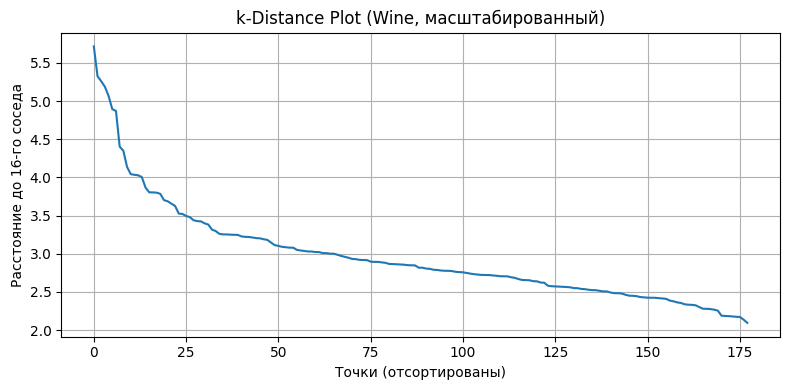

In [550]:
# YOUR CODE HERE
# 1. Масштабируйте X_wine с помощью StandardScaler
# 2. Постройте k-distance plot (k=4)
# 3. Визуально определите «локоть» и запишите подходящее eps

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)
k_wine = 16 # 2*d минус немножко, чтобы получить 3-ий кластер (в противном случае 2 кластера объединяются цепочкой в один) 
wine_nn = NearestNeighbors(n_neighbors=k_wine)
wine_nn.fit(X_wine_scaled)

distances_wine, ind_wine = wine_nn.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances_wine[:, -1])[::-1]

plt.figure(figsize=(8, 4))
if k_dist_wine is not None:
    plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [551]:
# YOUR CODE HERE
# 1. Запустите DBSCAN на X_wine_scaled с выбранным eps и min_samples=4
# 2. Выведите: число кластеров, число шумовых точек, долю шума
# 3. Если кластеров > 1, вычислите силуэт (исключив шум)

eps_wine = 2.4
dbscan_wine = DBSCAN(eps=eps_wine, min_samples=16)
labels_wine_dbscan = dbscan_wine.fit_predict(X_wine_scaled)

n_clusters = len(set(labels_wine_dbscan)) - (1 if -1 in labels_wine_dbscan else 0)
n_noise = (labels_wine_dbscan == -1).sum()
noise = n_noise / len(labels_wine_dbscan)

if n_clusters > 1:
    mask = labels_wine_dbscan != -1
    if len(set(labels_wine_dbscan[mask])) >= 2:
        score_dbscan_wine = silhouette_score(X_wine_scaled[mask], labels_wine_dbscan[mask])
    else:
        score_dbscan_wine = None
    

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров: {n_clusters}")
print(f"Число шумовых точек: {n_noise}")
print(f"Доля шума: {noise:.2%}")
if n_clusters > 1 and score_dbscan_wine is not None:
    print(f"Силуэт (без шума): {score_dbscan_wine:.3f}")
else:
    print("Силуэт: не вычислен (меньше 2 кластеров или нет данных)")

=== Результаты DBSCAN на Wine ===
Число кластеров: 3
Число шумовых точек: 82
Доля шума: 46.07%
Силуэт (без шума): 0.419


---
## Шаг 8. Анализ шумовых точек

Шумовые точки — это объекты, которые DBSCAN не смог отнести ни к одному кластеру. В задаче кластеризации они могут нести важную информацию.

In [552]:
# YOUR CODE HERE
# 1. Выберите строки X_wine, соответствующие шумовым точкам (labels_wine == -1)
# 2. Создайте DataFrame с признаками шумовых точек
# 3. Сравните среднее значение признаков шумовых точек
#    со средним по всей выборке (df_wine.mean())
# 4. Какие признаки у шумовых точек сильно отличаются от среднего?

noise_mask_wine = labels_wine_dbscan == -1

# Берем ОРИГИНАЛЬНЫЕ данные для интерпретации
X_wine_noise = X_wine[noise_mask_wine]
df_noise = pd.DataFrame(X_wine_noise, columns=feature_names)

print("=== Средние значения признаков (оригинальные данные) ===")
print(f"{'Признак':<30} {'Шум':>10} {'Все данные':>12} {'Разница':>10}")
print("-" * 65)

for col in feature_names:
    noise_mean = df_noise[col].mean()
    all_mean = df_wine[col].mean()
    diff = noise_mean - all_mean
    print(f"{col:<30} {noise_mean:10.2f} {all_mean:12.2f} {diff:10.2f}")

# 4. Признаки с сильным отличием
print("\n=== Топ-5 признаков с наибольшим отклонением ===")
diffs = {}
for col in feature_names:
    diffs[col] = abs(df_noise[col].mean() - df_wine[col].mean())

top_features = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:5]
for col, diff in top_features:
    print(f"{col}: разница {diff:.2f}")

=== Средние значения признаков (оригинальные данные) ===
Признак                               Шум   Все данные    Разница
-----------------------------------------------------------------
alcohol                             12.63        13.00      -0.37
malic_acid                           2.42         2.34       0.08
ash                                  2.36         2.37      -0.01
alcalinity_of_ash                   20.53        19.49       1.03
magnesium                           99.61        99.74      -0.13
total_phenols                        2.17         2.30      -0.12
flavanoids                           1.81         2.03      -0.22
nonflavanoid_phenols                 0.38         0.36       0.02
proanthocyanins                      1.53         1.59      -0.06
color_intensity                      4.42         5.06      -0.64
hue                                  0.94         0.96      -0.02
od280/od315_of_diluted_wines         2.44         2.61      -0.17
proline            

**❓ Вопрос для размышления:** Чем отличаются шумовые точки от остальных? Являются ли они «плохими» данными или это реальные аномалии?

Ответ: данные не являются ни плохими, ни аномалиями, скорее это следствие плохого выбора параметров. Кроме того, скорее всего данные плохо кластерно-разделимы, поэтому возникает такая проблема. Ключевое - "локоть", называемый в теории (лекция Паши) крутой и важной штукой сложно найти на графике, не опираясь на данные о кол-ве кластеров и проценте шума. 

---
## Шаг 9. Итоговое сравнение: DBSCAN vs K-Means на Wine

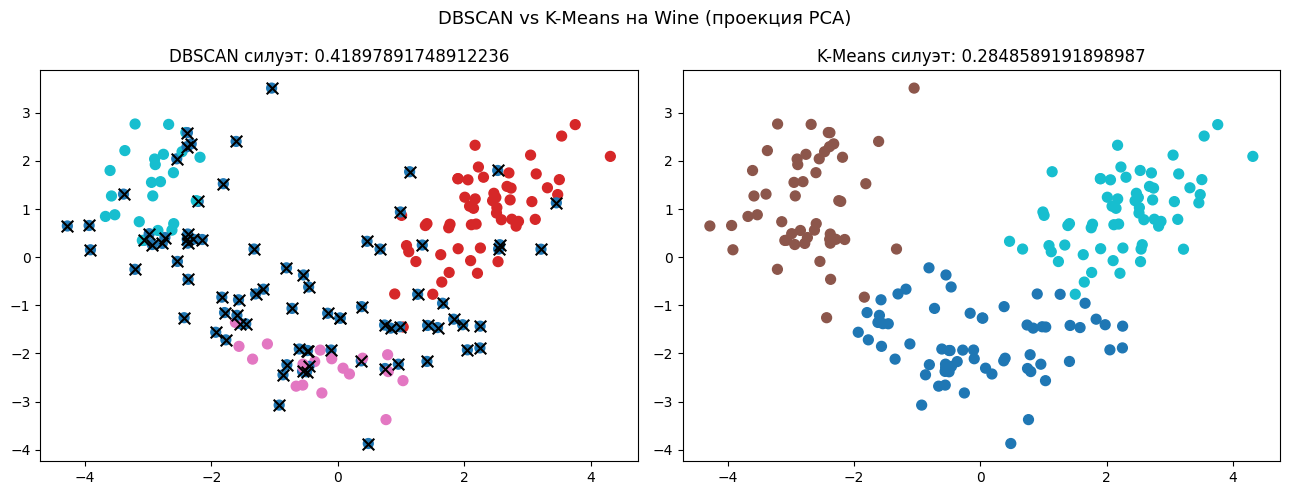

In [553]:
# YOUR CODE HERE
# 1. Обучите KMeans с числом кластеров = числу кластеров DBSCAN
#    (или с n_clusters=3, так как истинных классов 3)
# 2. Вычислите силуэт для K-Means
# 3. Сравните силуэт DBSCAN и K-Means
# 4. Визуализируйте результаты обоих методов в 2D (первые два признака
#    после масштабирования или используйте PCA до 2 компонент)

# Подсказка для PCA:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# DBSCAN
# для него уже есть dbscan_wine (модель), score_wine (силуэт) и labels_wine (предсказания)

# K-Means
kmeans_wine = KMeans(n_clusters=3, random_state=RANDOM_STATE)
labels_wine_kmeans = kmeans_wine.fit_predict(X_wine_scaled)

score_kmeans_wine = silhouette_score(X_wine_scaled, labels_wine_kmeans)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# DBSCAN
axes[0].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_wine_dbscan, s=50, alpha=1, cmap='tab10', label='DBSCAN: ', marker='o')
axes[0].scatter(X_wine_2d[labels_wine_dbscan == -1, 0], X_wine_2d[labels_wine_dbscan == -1, 1], c='black', s=70, alpha=1,  marker='x')
axes[0].set_title(f"DBSCAN силуэт: {score_dbscan_wine}")
# K-Means
axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_wine_kmeans, s=50, alpha=1, cmap='tab10', label='DBSCAN: ', marker='o')
axes[1].scatter(X_wine_2d[labels_wine_kmeans == -1, 0], X_wine_2d[labels_wine_kmeans == -1, 1], c='black', s=70, alpha=1,  marker='x')
axes[1].set_title(f"K-Means силуэт: {score_kmeans_wine}")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 10. Итоговые выводы

Ответьте на следующие вопросы в ячейке ниже (текст Markdown):

**1. Когда DBSCAN выигрывает у K-Means?**

> Когда искомое разделение данных нелинейно (кластеры образуют более сложную, чем сферическую, форму).

**2. Когда K-Means предпочтительнее?**

> Данные в многомерном пространстве образуют сферическую форму, данные линейно разделимы.

**3. Почему масштабирование обязательно для DBSCAN?**

> Алгоритм меряет расстояния, чтобы создавать кластеры как цепочки объектов. При отсутствии масштабирования по признаку, где расстояния меньше, появится один единственный кластер. Признак же с бОльшим разбросом данных будет иметь много шума. Объединяя эти условия, получим много шума и неправильное разделение данных на кластеры. 

**4. Как интерпретировать шумовые точки в датасете Wine?**

> Скорее всего, так как датасет без выбросов и аномалий, шумовые точки стоит интерпретировать как ошибку в подборе гиперпараметров (где именно я её допустил - не знаю... перебирал всё от eps до n_samples, правильного разбиения с низким шумом так и не получил).

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

> Нет, нельзя. Причина - зависимости, которые может описывать DBSCAN, не обязаны быть линейными (метрика силуэта считает расстояния между классами и внутри классов, значит если класс не округлой, а, например, вытянутой формы, силуэт покажет "плохие" значения). Кроме того, силуэт не штрафует dbscan за создание шума. Из этого следует, что и высокое значение силуэта не гарантирует качественное разбиение с помощью dbscan на кластеры. Для корректного сравнения лучше использовать другие метрики (например, Fin, Fout и другие).